
# 6. Digitalni filtri – načrtovanje in uporaba


## 6.1 Vrste digitalnih filtrov
- KEO - Končni Enotin Odziv (FIR) in
- NEO - Neskončni Enotin Odziv (IIR).

### 6.2 Načrtovanje (KEO/NEO) filtrov
- FIR (KEO): okensko načrtovanje, Parks–McClellan (`remez`), linearna faza.
- IIR (NEO): Butterworth, Chebyshev, Elliptic; realizacija v SOS.

> Opomba: če je v zapiskih kratica "NEO", tukaj pokrivamo **oba**: KIO (FIR) in NIO (IIR).
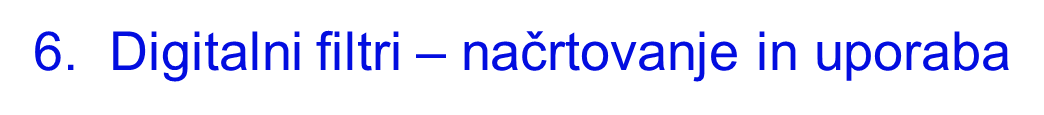
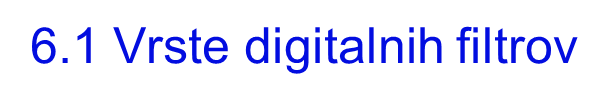

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.grid'] = True


#### Primer FIR (KEO): nizkoprepustni filter z oknom (Kaiser)

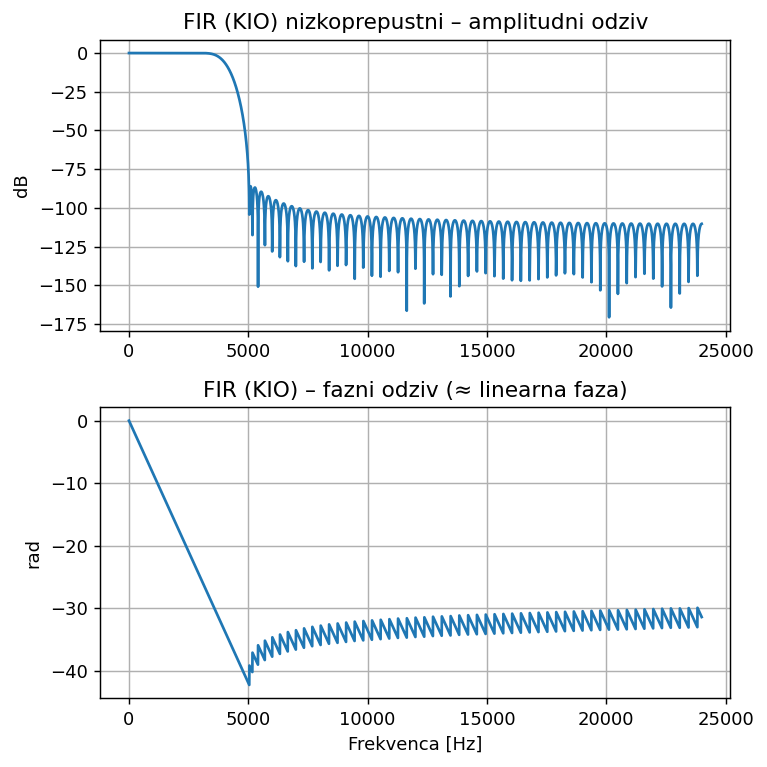

In [2]:

fs = 48000
numtaps = 129
fc = 4000  # Hz
beta = 8.6
b = signal.firwin(numtaps, fc, fs=fs, window=('kaiser', beta))
w, h = signal.freqz(b, worN=4096, fs=fs)
fig, axs = plt.subplots(2,1, figsize=(6,6))
axs[0].plot(w, 20*np.log10(np.maximum(np.abs(h),1e-10)))
axs[0].set_title('FIR (KEO) nizkoprepustni – amplitudni odziv')
axs[0].set_ylabel('dB')
axs[1].plot(w, np.unwrap(np.angle(h)))
axs[1].set_title('FIR (KEO) – fazni odziv (≈ linearna faza)')
axs[1].set_xlabel('Frekvenca [Hz]'); axs[1].set_ylabel('rad')
plt.tight_layout()


#### 6.2.1 FIR (KEO) Filtri: Okensko načrtovanje in optimalni filtri
Primerjali bomo tri različne pristope načrtovanja KEO filtrov:
1. **Kaiserjevo okno:** Omogoča prilagajanje širine glavnega reznja in dušenja stranskih režnjev.
2. **Pravokotno okno (Boxcar):** Najosnovnejše okno, ki ponuja najožji glavni reženj, a zelo slabo dušenje (visoko valovitost).
3. **Optimalni filter (Remez/Parks-McClellan):** Minimizira maksimalno napako v prepustnem in zapornem pasu (enakomerna valovitost oz. *equiripple*).

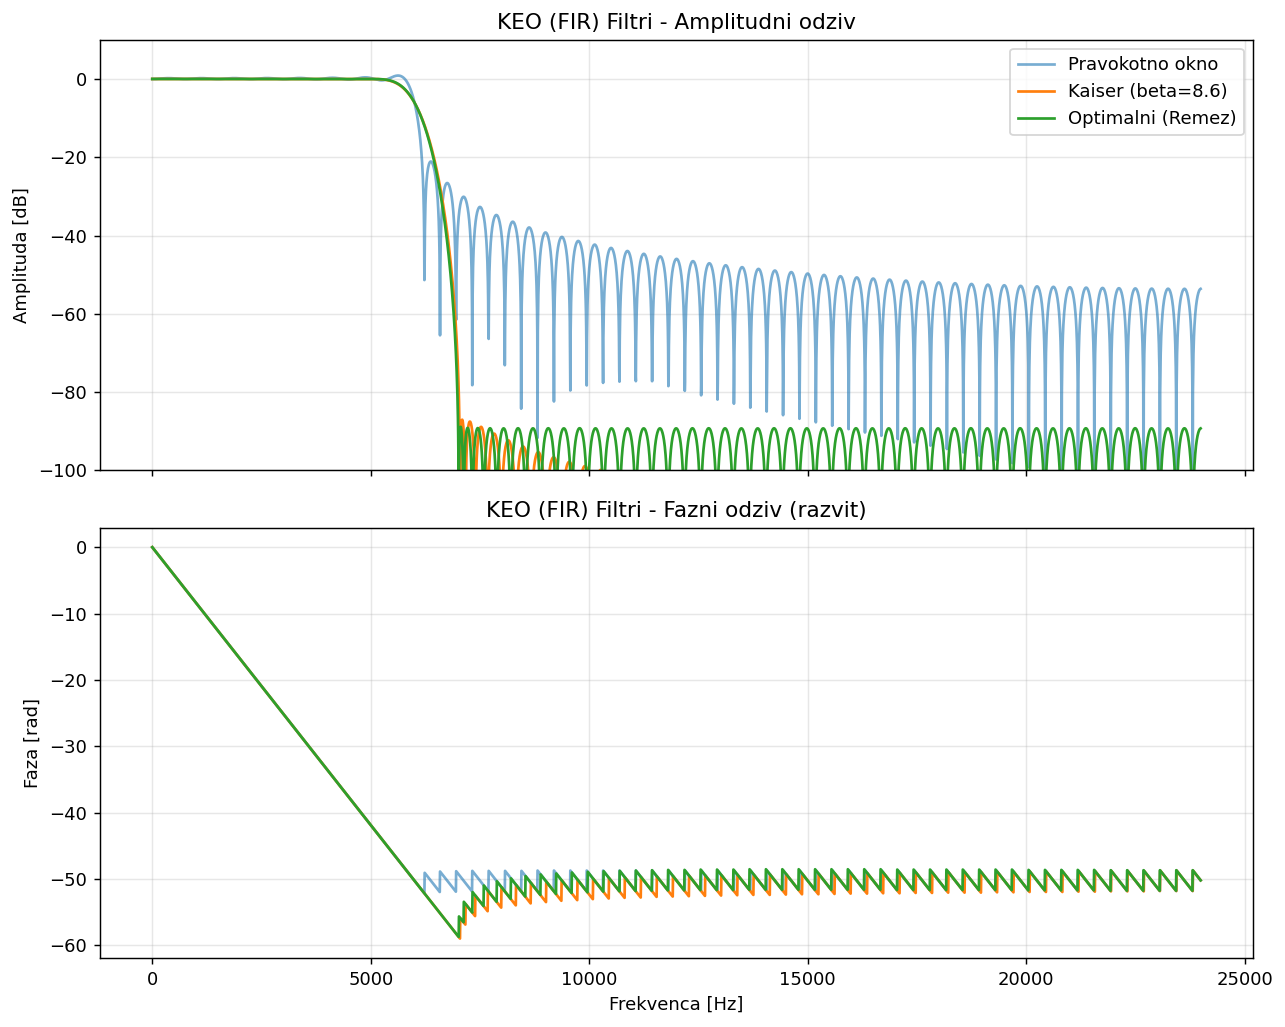

In [8]:
# KEO (FIR) Filtri - Amplitudni in fazni odziv
fs = 48000
numtaps = 129
fc = 6000
bands = [0, 5000, 7000, 24000]
desired = [1, 0]

b_kaiser = signal.firwin(numtaps, fc, fs=fs, window=('kaiser', 8.6))
w_k, h_kaiser = signal.freqz(b_kaiser, worN=4096, fs=fs)

b_rect = signal.firwin(numtaps, fc, fs=fs, window='boxcar')
w_r, h_rect = signal.freqz(b_rect, worN=4096, fs=fs)

b_remez = signal.remez(numtaps, bands, desired, fs=fs)
w_rm, h_remez = signal.freqz(b_remez, worN=4096, fs=fs)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Amplitudni odziv
ax1.plot(w_r, 20*np.log10(np.maximum(np.abs(h_rect), 1e-10)), label='Pravokotno okno', alpha=0.6)
ax1.plot(w_k, 20*np.log10(np.maximum(np.abs(h_kaiser), 1e-10)), label='Kaiser (beta=8.6)')
ax1.plot(w_rm, 20*np.log10(np.maximum(np.abs(h_remez), 1e-10)), label='Optimalni (Remez)')
ax1.set_title('KEO (FIR) Filtri - Amplitudni odziv')
ax1.set_ylabel('Amplituda [dB]')
ax1.set_ylim([-100, 10])
ax1.grid(True, alpha=0.3)
ax1.legend()

# Fazni odziv
ax2.plot(w_r, np.unwrap(np.angle(h_rect)), alpha=0.6)
ax2.plot(w_k, np.unwrap(np.angle(h_kaiser)))
ax2.plot(w_rm, np.unwrap(np.angle(h_remez)))
ax2.set_title('KEO (FIR) Filtri - Fazni odziv (razvit)')
ax2.set_xlabel('Frekvenca [Hz]')
ax2.set_ylabel('Faza [rad]')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Primer IIR (NEO): eliptični nizkoprepustni in SOS realizacija

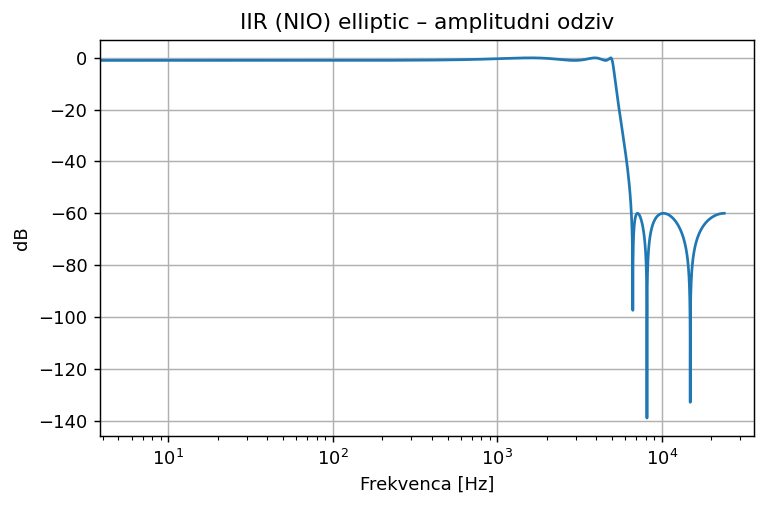

In [3]:

fs = 48000
wp = 5000
ws = 7000
gpass, gstop = 1, 60
N, Wn = signal.ellipord(wp, ws, gpass, gstop, fs=fs)
sos = signal.ellip(N, gpass, gstop, Wn, output='sos', fs=fs)
w, h = signal.sosfreqz(sos, worN=4096, fs=fs)
plt.figure(figsize=(6,4))
plt.semilogx(w, 20*np.log10(np.maximum(np.abs(h),1e-12)))
plt.title('IIR (NEO) elliptic – amplitudni odziv'); plt.xlabel('Frekvenca [Hz]'); plt.ylabel('dB'); plt.tight_layout()


#### 6.2.2 IIR (NEO) Filtri: Klasične aproksimacije
NEO filtri dosegajo strme prehode z bistveno nižjim redom kot KEO filtri. Vendar pa je njihova glavna pomanjkljivost **nelinearna faza**, zlasti v prehodnem območju (okoli frekvence reza). Besslov filter je izjema, saj je načrtovan posebej za linearno fazo v prepustnem pasu, a zato žrtvuje strmino reza.

Za zagotavljanje numerične stabilnosti se realizirajo s pomočjo SOS struktur (Second-Order Sections).

Preizkusili bomo:
1. **Butterworth:** Maksimalno raven odziv v prepustnem pasu (brez valovitosti).
2. **Chebyshev (Tip I):** Strmejši prehod, a dopušča valovitost v prepustnem pasu.
3. **Bessel:** Poudarek na maksimalno ravnem faznem odzivu (konstantna skupinska zakasnitev), a zelo blag prehod.
4. **Elliptic (Cauer):** Najstrmejši prehod za dani red, valovitost v prepustnem in zapornem pasu.

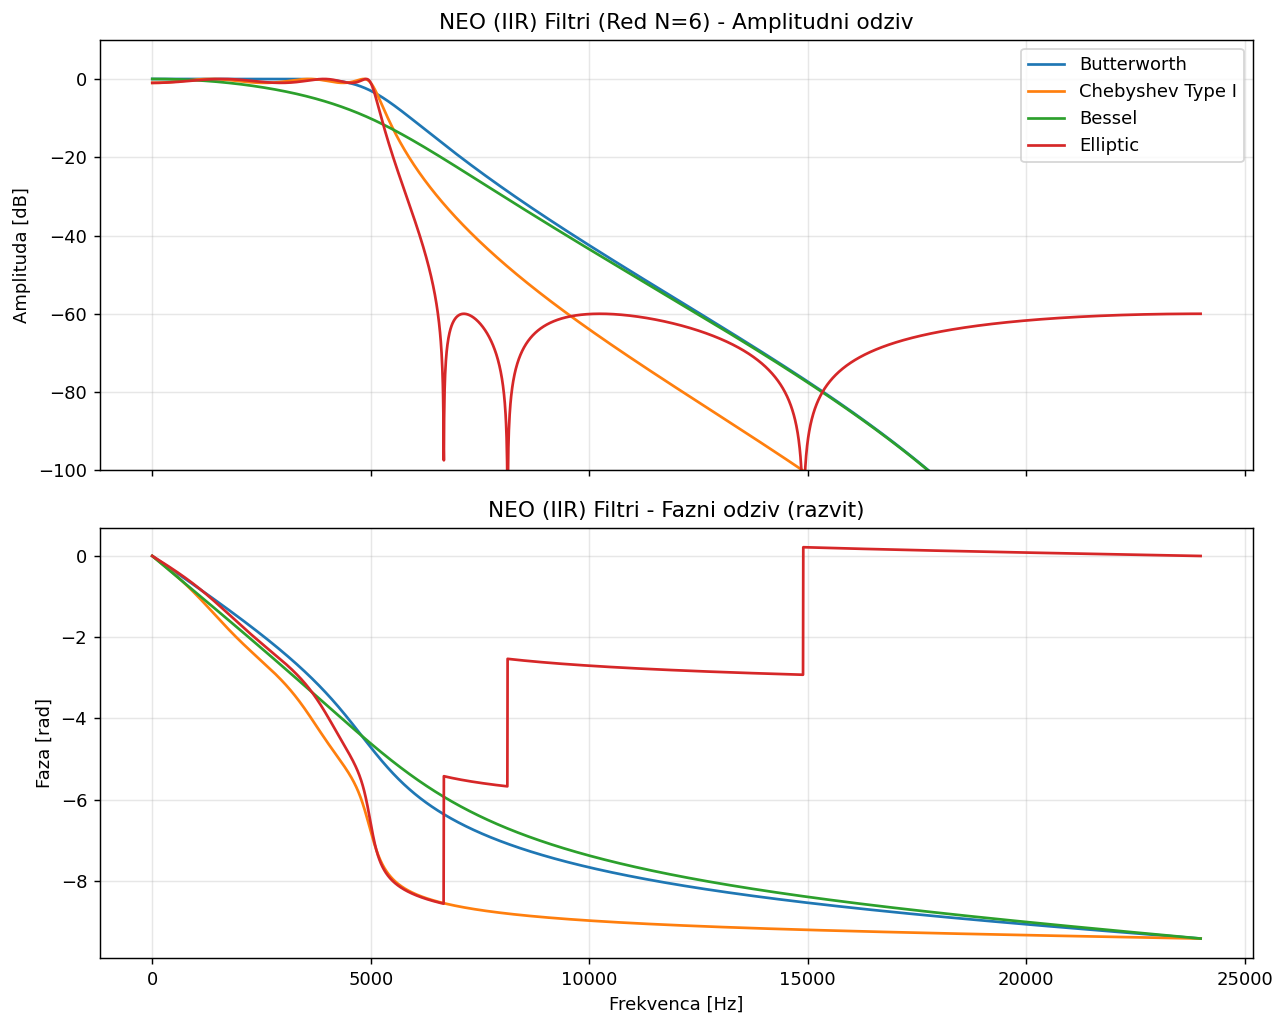

In [9]:
# NEO (IIR) Filtri - Amplitudni in fazni odziv
wp = 5000
ws = 7000
gpass = 1
gstop = 60

N_iir, Wn_iir = signal.ellipord(wp, ws, gpass, gstop, fs=fs)

sos_ellip = signal.ellip(N_iir, gpass, gstop, Wn_iir, output='sos', fs=fs)
w_e, h_ellip = signal.sosfreqz(sos_ellip, worN=4096, fs=fs)

sos_butter = signal.butter(N_iir, wp, btype='low', output='sos', fs=fs)
w_b, h_butter = signal.sosfreqz(sos_butter, worN=4096, fs=fs)

sos_cheby = signal.cheby1(N_iir, gpass, wp, btype='low', output='sos', fs=fs)
w_c, h_cheby = signal.sosfreqz(sos_cheby, worN=4096, fs=fs)

sos_bessel = signal.bessel(N_iir, wp, btype='low', output='sos', fs=fs)
w_bes, h_bessel = signal.sosfreqz(sos_bessel, worN=4096, fs=fs)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Amplitudni odziv
ax1.plot(w_b, 20*np.log10(np.maximum(np.abs(h_butter), 1e-12)), label='Butterworth')
ax1.plot(w_c, 20*np.log10(np.maximum(np.abs(h_cheby), 1e-12)), label='Chebyshev Type I')
ax1.plot(w_bes, 20*np.log10(np.maximum(np.abs(h_bessel), 1e-12)), label='Bessel')
ax1.plot(w_e, 20*np.log10(np.maximum(np.abs(h_ellip), 1e-12)), label='Elliptic')
ax1.set_title(f'NEO (IIR) Filtri (Red N={N_iir}) - Amplitudni odziv')
ax1.set_ylabel('Amplituda [dB]')
ax1.set_ylim([-100, 10])
ax1.grid(True, alpha=0.3)
ax1.legend()

# Fazni odziv
ax2.plot(w_b, np.unwrap(np.angle(h_butter)))
ax2.plot(w_c, np.unwrap(np.angle(h_cheby)))
ax2.plot(w_bes, np.unwrap(np.angle(h_bessel)))
ax2.plot(w_e, np.unwrap(np.angle(h_ellip)))
ax2.set_title('NEO (IIR) Filtri - Fazni odziv (razvit)')
ax2.set_xlabel('Frekvenca [Hz]')
ax2.set_ylabel('Faza [rad]')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 6.3 Posebna primerjava: Amplitudni odziv (KEO vs NEO)
Vzemimo najboljša predstavnika iz obeh skupin glede na strmino reza: **Optimalni FIR (Remez)** in **Eliptični IIR**.
* **NEO (Eliptični):** Doseže izjemno strm prehod in globoko dušenje pri zelo nizkem redu filtra, kar pomeni nizko računsko zahtevnost.
* **KEO (Remez):** Zahteva precej višji red (in s tem več operacij) za doseganje podobnih amplitudnih specifikacij kot IIR.

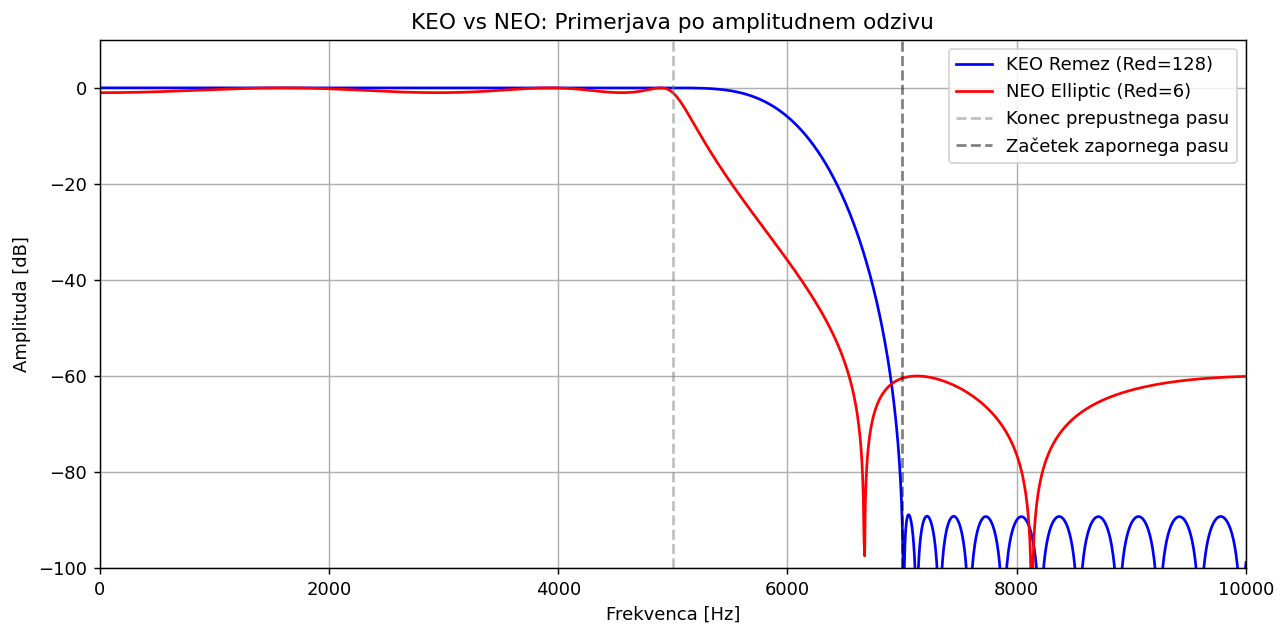

In [6]:
# Amplitudna primerjava najboljših KEO in NEO
plt.figure(figsize=(10, 5))
plt.plot(w_rm, 20*np.log10(np.maximum(np.abs(h_remez), 1e-10)), label=f'KEO Remez (Red={numtaps-1})', color='blue')
plt.plot(w_e, 20*np.log10(np.maximum(np.abs(h_ellip), 1e-12)), label=f'NEO Elliptic (Red={N_iir})', color='red')
plt.axvline(wp, color='gray', linestyle='--', alpha=0.5, label='Konec prepustnega pasu')
plt.axvline(ws, color='black', linestyle='--', alpha=0.5, label='Začetek zapornega pasu')
plt.title('KEO vs NEO: Primerjava po amplitudnem odzivu')
plt.xlabel('Frekvenca [Hz]')
plt.ylabel('Amplituda [dB]')
plt.ylim([-100, 10])
plt.xlim([0, 10000]) # Poudarek na prehodnem pasu
plt.legend()
plt.tight_layout()
plt.show()

#### 6.4 Posebna primerjava: Fazni odziv in linearnost faza (NEO vs KEO)
V tej primerjavi si poglejmo obnašanje faze pri treh izbranih filtrih:
1. **KEO (Remez):** Strogo linearna faza (premica na grafu).
2. **NEO (Eliptični):** Visoko nelinearna faza, zlasti na robu prepustnega pasu in v prehodu, kar povzroča popačenja.
3. **NEO (Bessel):** IIR filter, ki poskuša posnemati linearnost faze FIR filtrov v prepustnem pasu. Faza je veliko bolj linearna kot pri eliptičnem, a kot smo videli zgoraj, to plača s poraznim amplitudnim odzivom (zelo blag prehod).

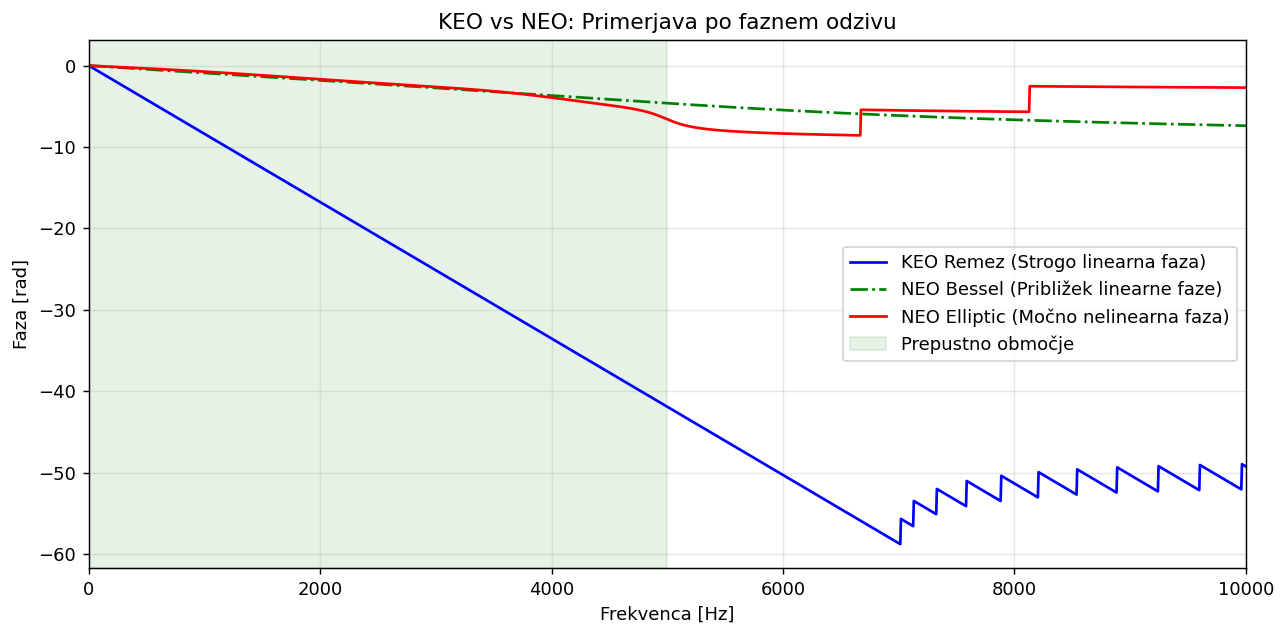

In [11]:
# Fazna primerjava z dodanim Besslovim filtrom
phase_remez = np.unwrap(np.angle(h_remez))
phase_ellip = np.unwrap(np.angle(h_ellip))
phase_bessel = np.unwrap(np.angle(h_bessel))

plt.figure(figsize=(10, 5))
plt.plot(w_rm, phase_remez, label='KEO Remez (Strogo linearna faza)', color='blue')
plt.plot(w_bes, phase_bessel, label='NEO Bessel (Približek linearne faze)', color='green', linestyle='-.')
plt.plot(w_e, phase_ellip, label='NEO Elliptic (Močno nelinearna faza)', color='red')

# Grafično označimo prepustno območje, kjer nas faza najbolj zanima
plt.axvspan(0, wp, color='green', alpha=0.1, label='Prepustno območje')

plt.title('KEO vs NEO: Primerjava po faznem odzivu')
plt.xlabel('Frekvenca [Hz]')
plt.ylabel('Faza [rad]')
plt.xlim([0, 10000]) # Prikaz območja interesa okoli frekvence reza
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### 6.5 Pomen linearne faze v časovnem prostoru (Teoretični model)
Zakaj je linearna faza tako pomembna? Signal običajno ni sestavljen iz le ene frekvence, temveč iz več frekvenčnih komponent (osnovna frekvenca in njeni harmoniki). Da se oblika signala pri prehodu skozi filter ohrani, se morajo **vse frekvenčne komponente zakasniti za popolnoma enak čas**.

Matematično je časovna zakasnitev (skupinska zakasnitev) definirana kot odvod faze po frekvenci. Če želimo, da je ta časovna zakasnitev konstantna, mora biti faza **linearna funkcija frekvence**.

**Pravilo:** Če se frekvenca podvoji, se mora za ohranitev enake časovne zakasnitve podvojiti tudi fazni kot.
* Če osnovna frekvenca $f_1$ (1 kHz) dobi fazni zamik $-\pi/2$ (kar ustreza četrtini njene periode), mora prva harmonska frekvenca $2f_1$ (2 kHz) dobiti sorazmeren fazni zamik $-\pi$ (pol njene periode, kar je časovno povsem enako).
* V spodnjem primeru bomo ta pojav vizualizirali z **idealnim teoretičnim sistemom** (amplituda se ne spremeni, spreminjamo izključno fazo). Dodali smo grafa amplitudnega in faznega odziva tega idealnega sistema, da boste natančno videli razliko med linearno premico in nelinearno krivuljo.

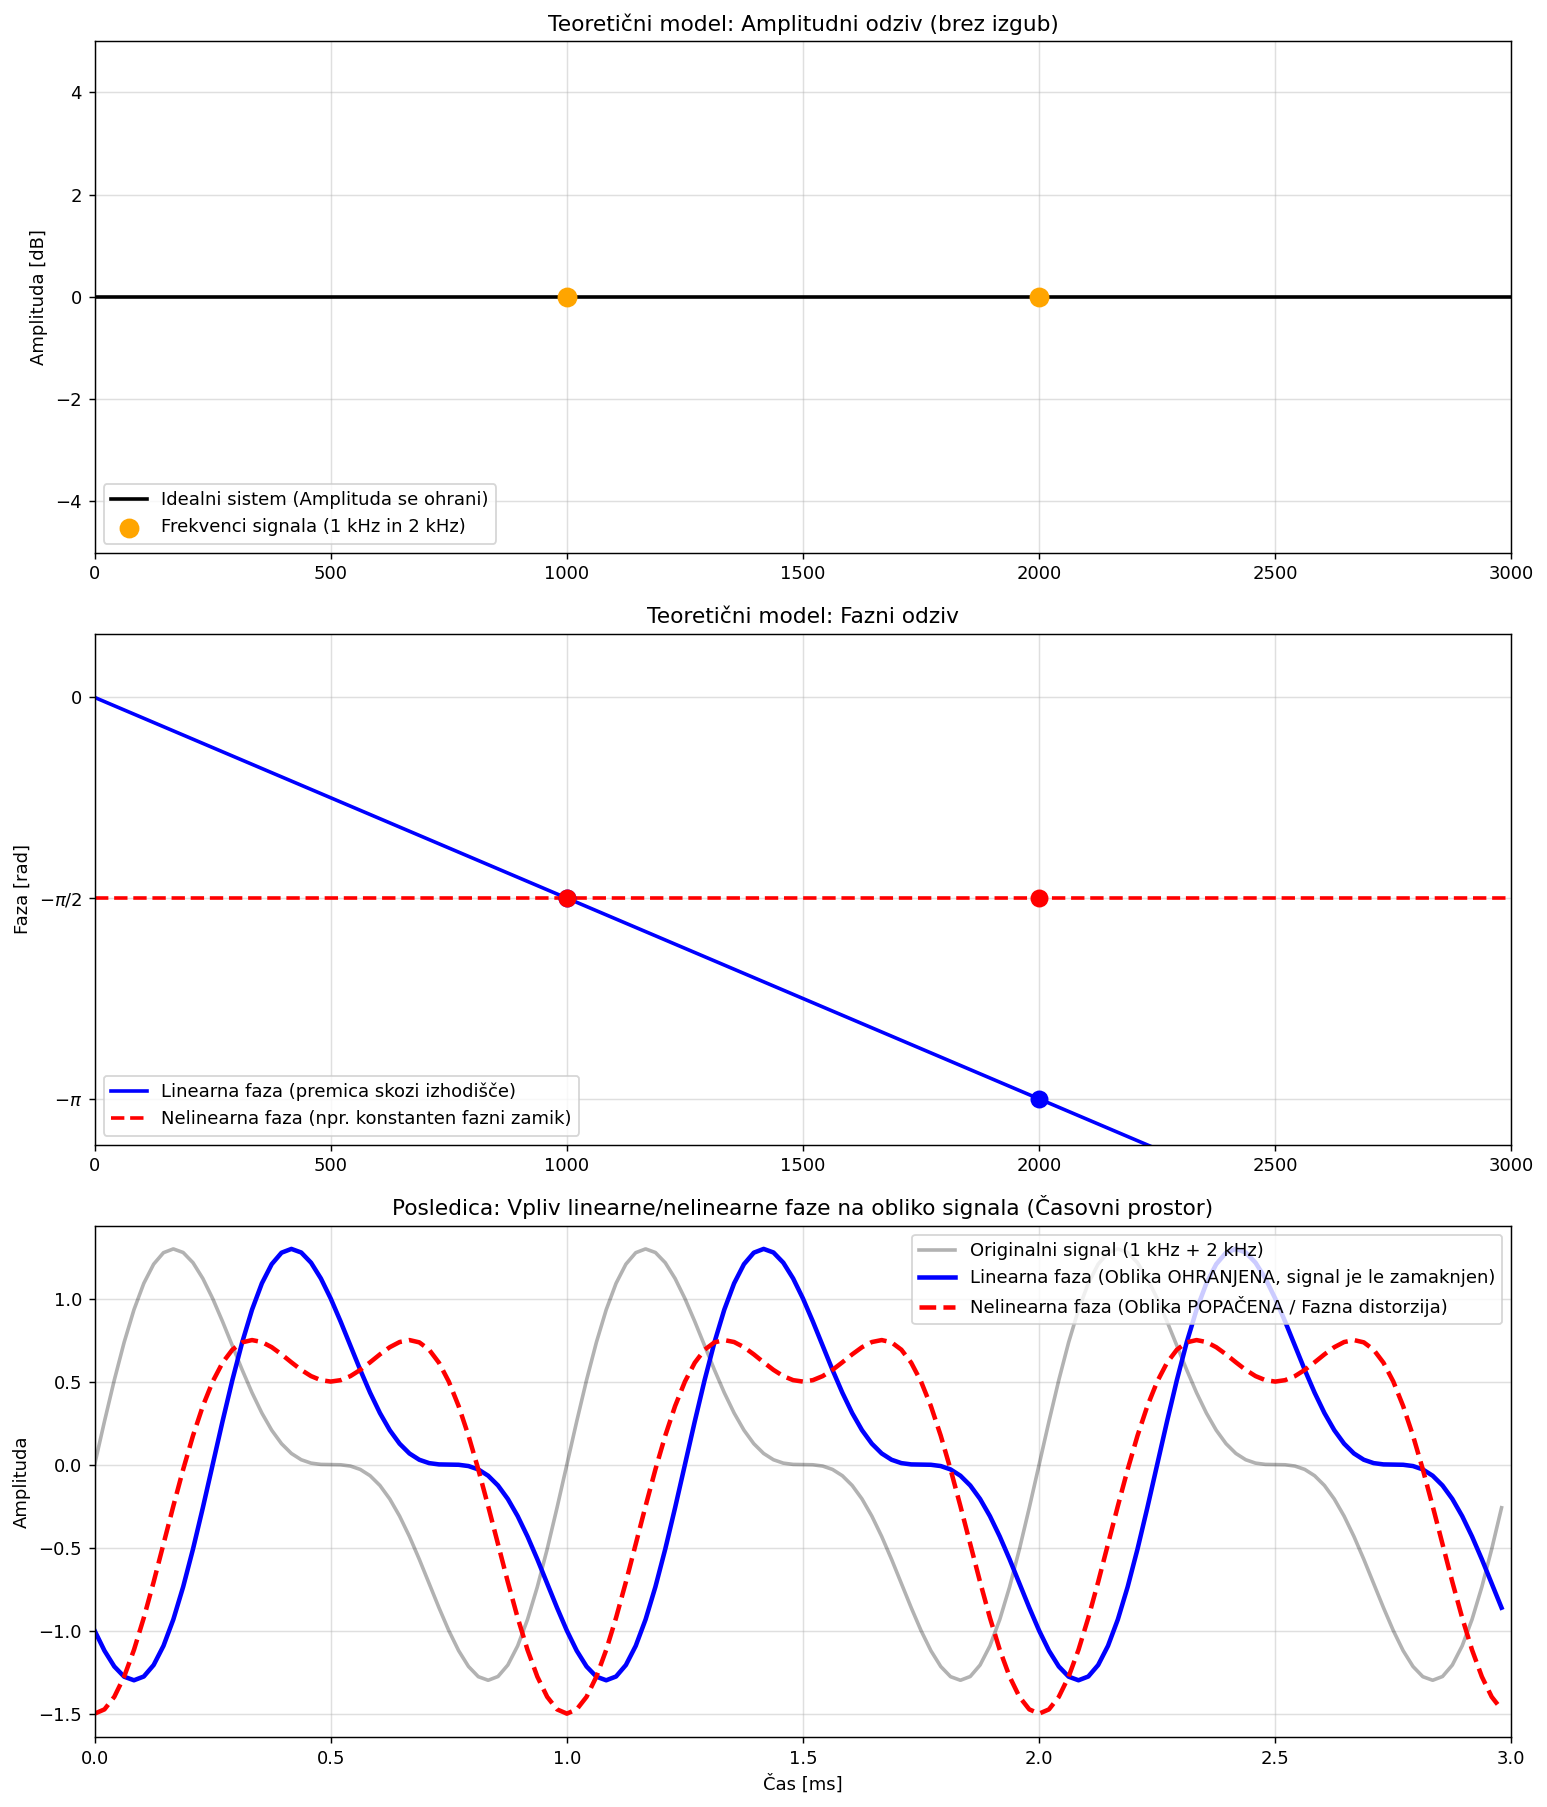

In [16]:
# Prikaz pomembnosti linearne faze z idealiziranim teoretičnim modelom
fs_demo = 48000
t = np.linspace(0, 0.003, int(0.003 * fs_demo), endpoint=False) # 3 ms časa
f1 = 1000 # Osnovna frekvenca: 1 kHz
f2 = 2000 # Prvi harmonik: 2 kHz (dvakratnik f1)

# 1. Originalni signal (sestavljen iz f1 in f2 z določenim amplitudnim razmerjem)
sig_orig = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

# 2. Sistem z LINEARNO fazo (vse se zakasni za enak ČAS)
# Faza mora sorazmerno naraščati s frekvenco (premica skozi izhodišče)
phi1_lin = -np.pi / 2  # f1 se premakne za četrtino periode
phi2_lin = -np.pi      # f2 (2x hitrejša) se mora za ISTI čas premakniti za pol periode
sig_linear = np.sin(2 * np.pi * f1 * t + phi1_lin) + 0.5 * np.sin(2 * np.pi * f2 * t + phi2_lin)

# 3. Sistem z NELINEARNO fazo (komponente se zakasnijo za različen čas)
# Simuliramo nelinearnost: sistem npr. obema frekvencama dodeli ENAK fazni zamik
phi1_nonlin = -np.pi / 2
phi2_nonlin = -np.pi / 2 # Napaka: faza pri 2 kHz bi morala biti dvakratnik tiste pri 1 kHz!
sig_nonlin = np.sin(2 * np.pi * f1 * t + phi1_nonlin) + 0.5 * np.sin(2 * np.pi * f2 * t + phi2_nonlin)

# --- Priprava grafov (3 podgrafi en pod drugim) ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14))

# Frekvenčna os za prva dva grafa
f_axis = np.linspace(0, 3000, 400)

# --- 1. Amplitudni odziv (Idealen, 0 dB) ---
ax1.plot(f_axis, np.zeros_like(f_axis), color='black', label='Idealni sistem (Amplituda se ohrani)', linewidth=2)
ax1.scatter([f1, f2], [0, 0], color='orange', s=100, zorder=5, label='Frekvenci signala (1 kHz in 2 kHz)')
ax1.set_title('Teoretični model: Amplitudni odziv (brez izgub)')
ax1.set_ylabel('Amplituda [dB]')
ax1.set_ylim([-5, 5])
ax1.set_xlim([0, 3000])
ax1.grid(True, alpha=0.4)
ax1.legend(loc='lower left')

# --- 2. Fazni odziv ---
# Linearna faza je premica: phi(f) = -k * f
phase_lin_axis = - (np.pi / 2000) * f_axis
# Nelinearna faza (v našem simuliranem primeru konstantna vrednost -pi/2 za vse frekvence)
phase_nonlin_axis = - (np.pi / 2) * np.ones_like(f_axis)

ax2.plot(f_axis, phase_lin_axis, label='Linearna faza (premica skozi izhodišče)', color='blue', linewidth=2)
ax2.plot(f_axis, phase_nonlin_axis, label='Nelinearna faza (npr. konstanten fazni zamik)', color='red', linestyle='--', linewidth=2)
# Označimo vrednosti faze pri f1 in f2
ax2.scatter([f1, f2], [phi1_lin, phi2_lin], color='blue', s=80, zorder=5)
ax2.scatter([f1, f2], [phi1_nonlin, phi2_nonlin], color='red', s=80, zorder=5)

ax2.set_yticks([-np.pi, -np.pi/2, 0])
ax2.set_yticklabels([r'$-\pi$', r'$-\pi/2$', '0'])
ax2.set_title('Teoretični model: Fazni odziv')
ax2.set_ylabel('Faza [rad]')
ax2.set_xlim([0, 3000])
ax2.set_ylim([-3.5, 0.5])
ax2.grid(True, alpha=0.4)
ax2.legend(loc='lower left')

# --- 3. Časovni odziv (Posledica v časovnem prostoru) ---
ax3.plot(t * 1000, sig_orig, label='Originalni signal (1 kHz + 2 kHz)', color='black', alpha=0.3, linewidth=2)
ax3.plot(t * 1000, sig_linear, label='Linearna faza (Oblika OHRANJENA, signal je le zamaknjen)', color='blue', linewidth=2.5)
ax3.plot(t * 1000, sig_nonlin, label='Nelinearna faza (Oblika POPAČENA / Fazna distorzija)', color='red', linestyle='--', linewidth=2.5)
ax3.set_title('Posledica: Vpliv linearne/nelinearne faze na obliko signala (Časovni prostor)')
ax3.set_xlabel('Čas [ms]')
ax3.set_ylabel('Amplituda')
ax3.set_xlim([0, 3])
ax3.grid(True, alpha=0.4)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### 6.6 Ekstremni primer popačenja: Pravokotni signal
Pravokotni signal je idealen za testiranje faznega odziva, saj njegova oblika sloni na natančni časovni poravnavi osnovne frekvence in njenih lihih harmonikov. Spodaj smo združili vse tri ključne poglede:
1. **Amplitudni odziv:** Oba filtra (KEO Remez in NEO Eliptični) imata podobne karakteristike prepustnega in zapornega pasu.
2. **Fazni odziv:** Tu se skriva glavna razlika. KEO ima strogo linearno fazo, NEO pa zelo nelinearno (zlasti okoli frekvence reza).
3. **Časovni odziv:** Zaradi linearne faze KEO filter ohrani simetrično obliko pravokotnega signala (vidimo le simetrično "zvonjenje" zaradi odrezanih visokih frekvenc). Zaradi nelinearne faze pa NEO filter harmonike zakasni različno, kar popolnoma podre in asimetrično popači ovojnico signala.

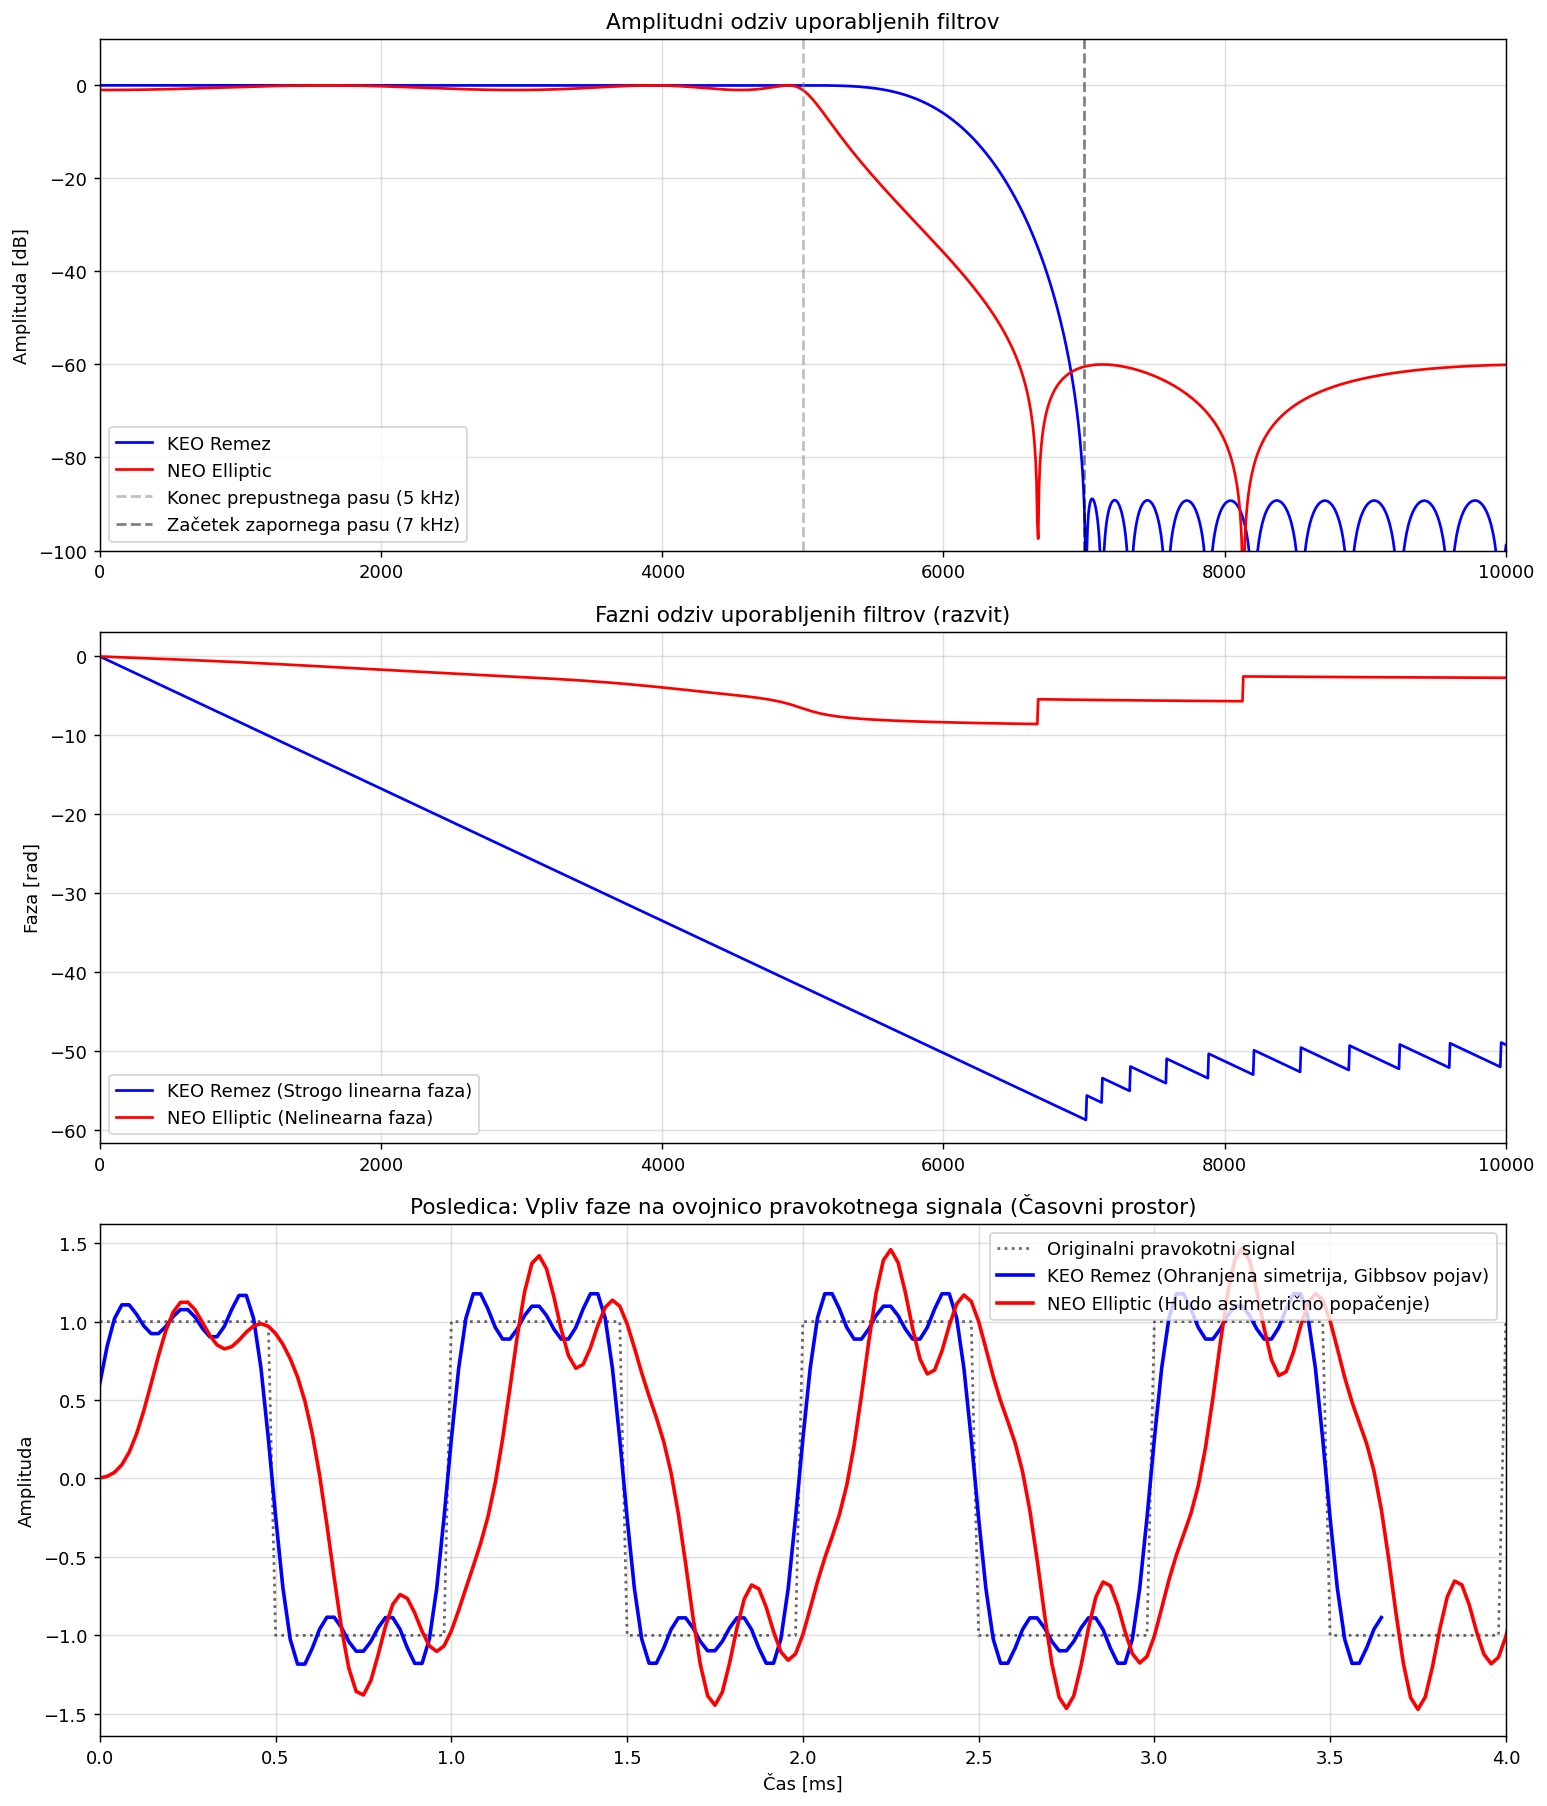

In [14]:
# Prikaz amplitudnega in faznega odziva ter vpliva na pravokotni signal

# 1. Izračun frekvenčnih odzivov uporabljenih filtrov
w_rm, h_remez = signal.freqz(b_remez, worN=4096, fs=fs)
w_e, h_ellip = signal.sosfreqz(sos_ellip, worN=4096, fs=fs)

# 2. Priprava časovnega pravokotnega signala
t_sq = np.linspace(0, 0.005, int(0.005 * fs), endpoint=False) # 5 ms časa
f_sq = 1000 # 1 kHz pravokotni signal
sq_wave = signal.square(2 * np.pi * f_sq * t_sq)

# VZROČNO FILTRIRANJE
sq_filtered_remez = signal.lfilter(b_remez, 1.0, sq_wave)
sq_filtered_ellip = signal.sosfilt(sos_ellip, sq_wave)

# Izris vseh treh grafov (3 podgrafi en pod drugim)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14))

# --- 1. Amplitudni odziv ---
ax1.plot(w_rm, 20*np.log10(np.maximum(np.abs(h_remez), 1e-10)), label='KEO Remez', color='blue')
ax1.plot(w_e, 20*np.log10(np.maximum(np.abs(h_ellip), 1e-12)), label='NEO Elliptic', color='red')
ax1.set_title('Amplitudni odziv uporabljenih filtrov')
ax1.set_ylabel('Amplituda [dB]')
ax1.set_ylim([-100, 10])
ax1.set_xlim([0, 10000]) # Fokus na območje do 10 kHz
ax1.axvline(wp, color='gray', linestyle='--', alpha=0.5, label='Konec prepustnega pasu (5 kHz)')
ax1.axvline(ws, color='black', linestyle='--', alpha=0.5, label='Začetek zapornega pasu (7 kHz)')
ax1.grid(True, alpha=0.4)
ax1.legend(loc='lower left')

# --- 2. Fazni odziv ---
ax2.plot(w_rm, np.unwrap(np.angle(h_remez)), label='KEO Remez (Strogo linearna faza)', color='blue')
ax2.plot(w_e, np.unwrap(np.angle(h_ellip)), label='NEO Elliptic (Nelinearna faza)', color='red')
ax2.set_title('Fazni odziv uporabljenih filtrov (razvit)')
ax2.set_ylabel('Faza [rad]')
ax2.set_xlim([0, 10000])
ax2.grid(True, alpha=0.4)
ax2.legend(loc='lower left')

# --- 3. Časovni odziv (Pravokotni signal) ---
ax3.plot(t_sq * 1000, sq_wave, label='Originalni pravokotni signal', color='black', linestyle=':', alpha=0.6)

# Kompenzacija konstantnega zamika za FIR, da se ga lažje vizualno primerja z originalom
zamik_remez = (numtaps - 1) / 2 / fs * 1000 # v ms
ax3.plot((t_sq * 1000) - zamik_remez, sq_filtered_remez,
         label='KEO Remez (Ohranjena simetrija, Gibbsov pojav)', color='blue', linewidth=2)

# Pri IIR faza ni linearna, zato zamika ne moremo enostavno odšteti
ax3.plot(t_sq * 1000, sq_filtered_ellip,
         label='NEO Elliptic (Hudo asimetrično popačenje)', color='red', linewidth=2)

ax3.set_title('Posledica: Vpliv faze na ovojnico pravokotnega signala (Časovni prostor)')
ax3.set_xlabel('Čas [ms]')
ax3.set_ylabel('Amplituda')
ax3.set_xlim([0, 4]) # Zoom na prve 4 ms
ax3.grid(True, alpha=0.4)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()